In [1]:
# ==========================================================
# AI-Assisted E-commerce Sales & Customer Analytics
# Exploratory Data Analysis (EDA)
# ==========================================================

# ==========================================================
# STEP 1 : Import Required Libraries
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==========================================================
# STEP 2 : Load Cleaned Datasets
# ==========================================================

customers = pd.read_csv("olist_customers_dataset.csv")

orders = pd.read_csv("olist_orders_dataset.csv")

order_items = pd.read_csv("olist_order_items_dataset.csv")

order_payments = pd.read_csv("olist_order_payments_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [3]:
# ==========================================================
# STEP 3 : Convert Date Columns
# ==========================================================

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [4]:
# ==========================================================
# STEP 4 : Merge Required Tables
# ==========================================================

merged_data = orders.merge(
    order_payments,
    on="order_id",
    how="left"
)

merged_data = merged_data.merge(
    customers,
    on="customer_id",
    how="left"
)

merged_data = merged_data.merge(
    order_items,
    on="order_id",
    how="left"
)

merged_data = merged_data.merge(
    products,
    on="product_id",
    how="left"
)

merged_data = merged_data.merge(
    order_reviews,
    on="order_id",
    how="left"
)

print("Datasets Merged Successfully!")

Datasets Merged Successfully!


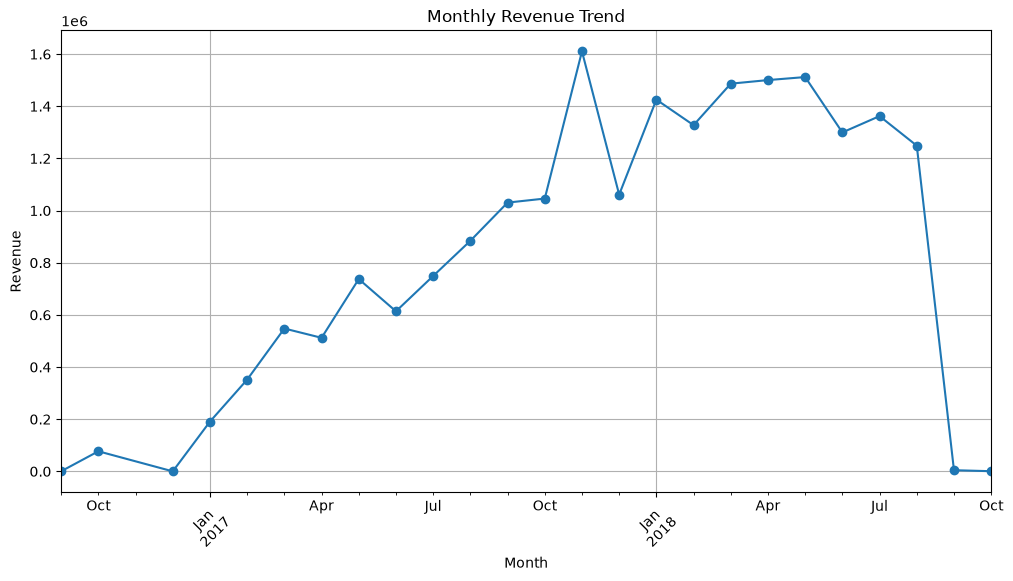

In [5]:
# ==========================================================
# Monthly Revenue Trend
# ==========================================================

merged_data["Year_Month"] = merged_data[
    "order_purchase_timestamp"
].dt.to_period("M")

monthly_revenue = merged_data.groupby(
    "Year_Month"
)["payment_value"].sum()

plt.figure(figsize=(12,6))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

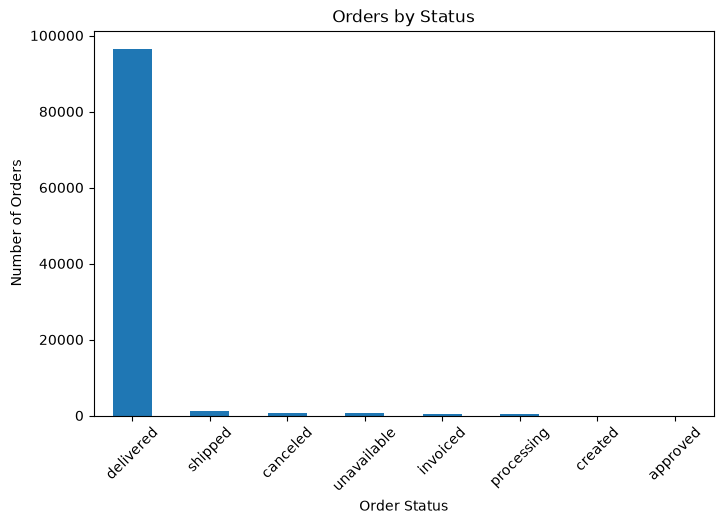

In [6]:
# ==========================================================
# Orders by Status
# ==========================================================

order_status = orders["order_status"].value_counts()

plt.figure(figsize=(8,5))

order_status.plot(kind="bar")

plt.title("Orders by Status")

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

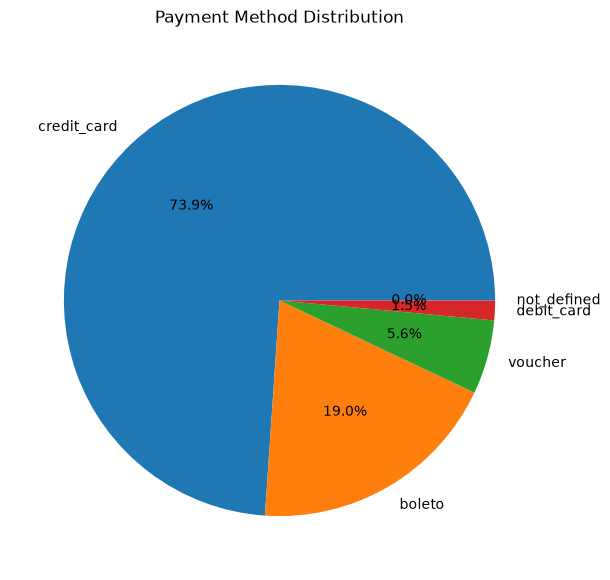

In [7]:
# ==========================================================
# Payment Method Distribution
# ==========================================================

payment_method = order_payments["payment_type"].value_counts()

plt.figure(figsize=(7,7))

payment_method.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Payment Method Distribution")

plt.show()

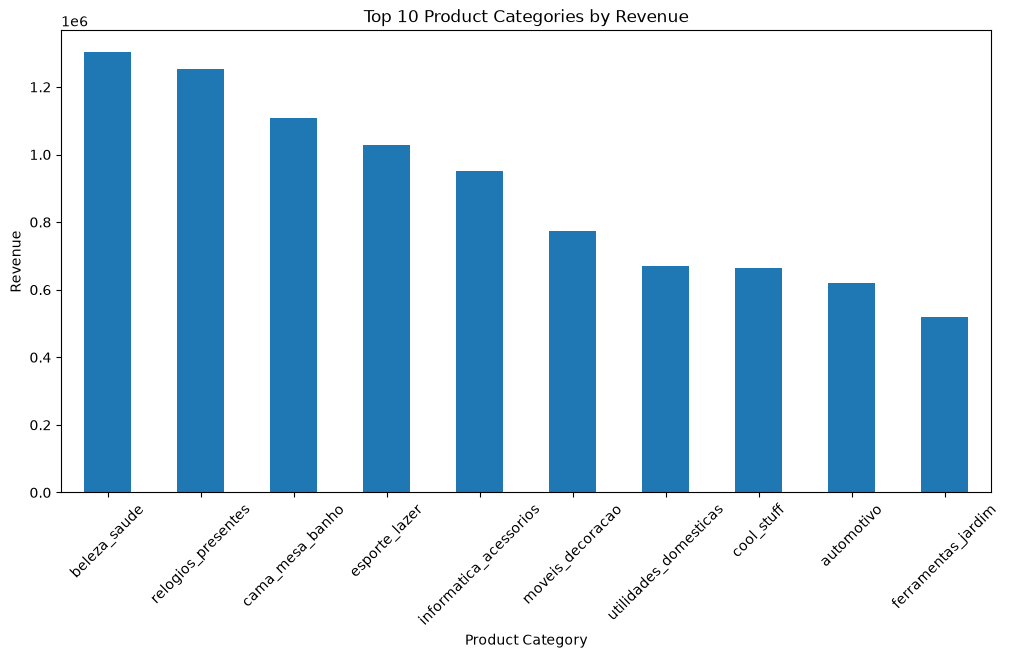

In [8]:
# ==========================================================
# Top 10 Product Categories by Revenue
# ==========================================================

category_sales = merged_data.groupby(
    "product_category_name"
)["price"].sum()

category_sales = category_sales.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

category_sales.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

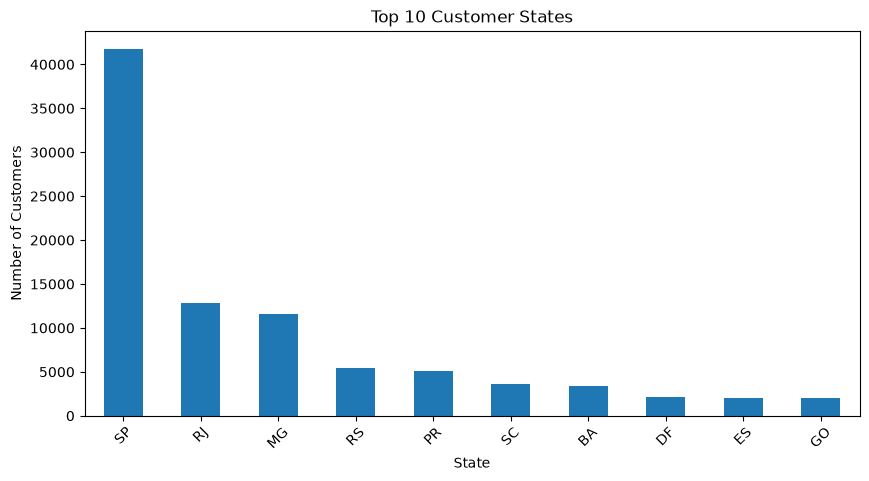

In [9]:
# ==========================================================
# Top 10 Customer States
# ==========================================================

customer_states = customers["customer_state"].value_counts().head(10)

plt.figure(figsize=(10,5))

customer_states.plot(kind="bar")

plt.title("Top 10 Customer States")

plt.xlabel("State")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

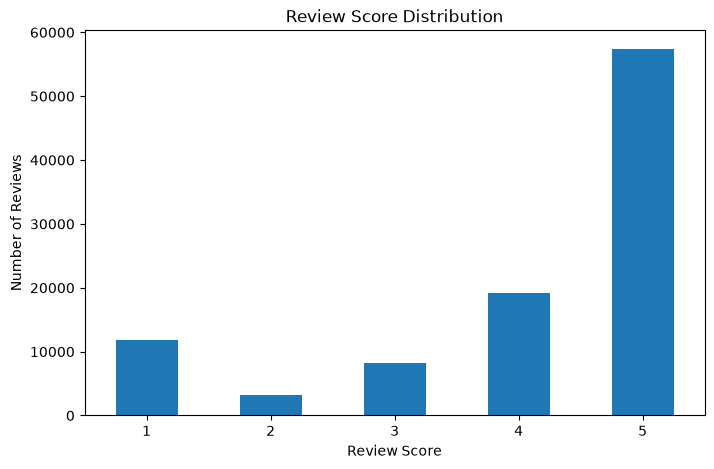

In [10]:
# ==========================================================
# Chart 6 : Review Score Distribution
# Purpose:
# Analyze customer satisfaction based on review scores.
# ==========================================================

review_scores = order_reviews["review_score"].value_counts().sort_index()

plt.figure(figsize=(8,5))

review_scores.plot(
    kind="bar"
)

plt.title("Review Score Distribution")

plt.xlabel("Review Score")

plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

In [12]:
# ==========================================================
# Convert Date Columns to Datetime
# ==========================================================

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"],
    errors="coerce"
)

# ==========================================================
# Calculate Delivery Time
# ==========================================================

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

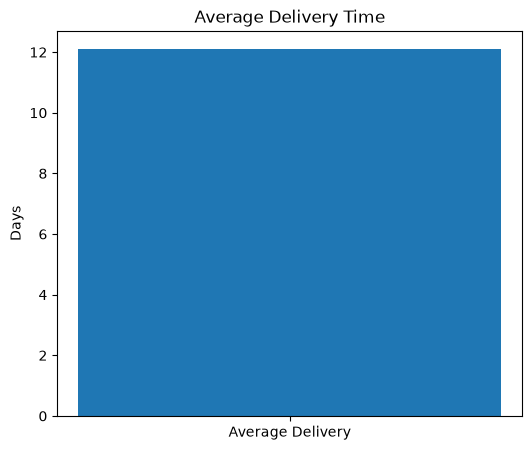

Average Delivery Time: 12.09 Days


In [13]:
# ==========================================================
# Chart 7 : Average Delivery Time
# ==========================================================

average_delivery = orders["delivery_days"].mean()

plt.figure(figsize=(6,5))

plt.bar(
    ["Average Delivery"],
    [average_delivery]
)

plt.title("Average Delivery Time")
plt.ylabel("Days")

plt.show()

print(f"Average Delivery Time: {average_delivery:.2f} Days")

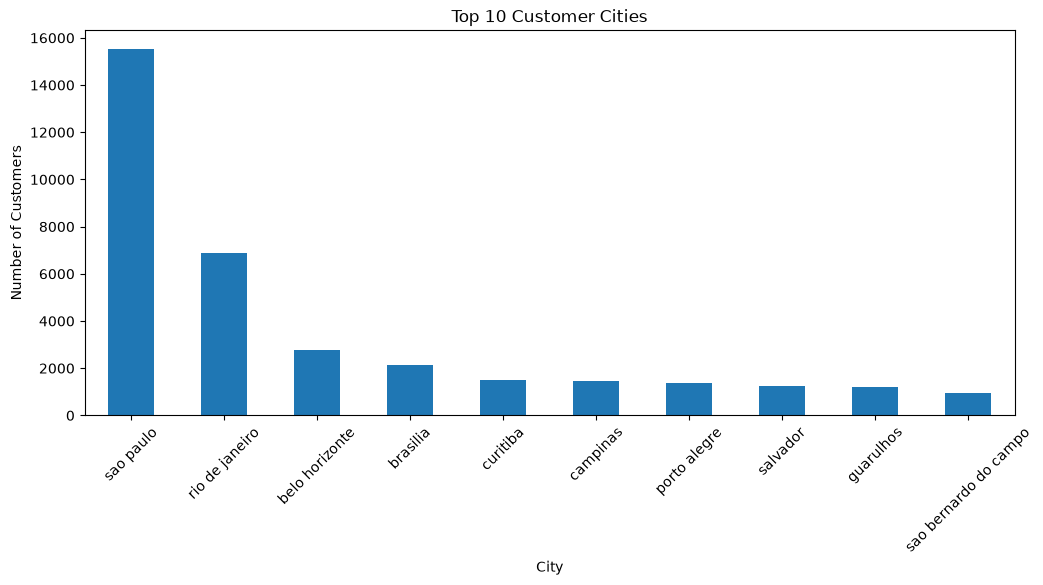

In [14]:
# ==========================================================
# Chart 8 : Top 10 Customer Cities
# Purpose:
# Identify cities with the highest number of customers.
# ==========================================================

top_cities = customers["customer_city"].value_counts().head(10)

plt.figure(figsize=(12,5))

top_cities.plot(
    kind="bar"
)

plt.title("Top 10 Customer Cities")

plt.xlabel("City")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

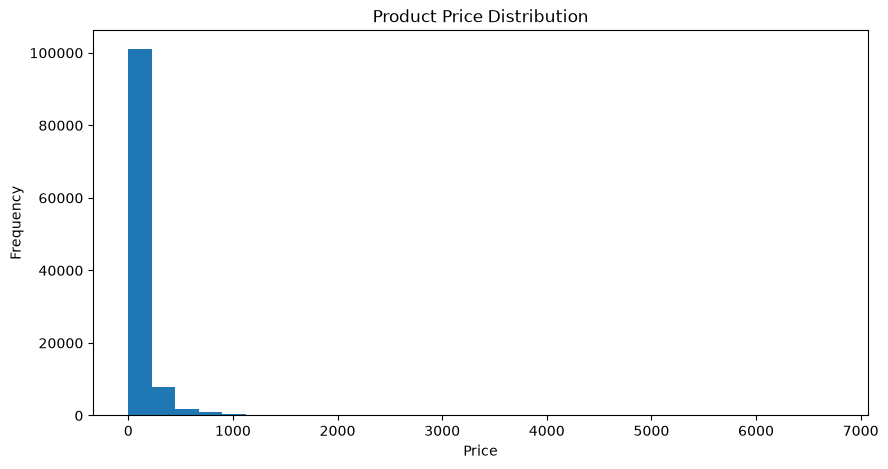

In [15]:
# ==========================================================
# Chart 9 : Product Price Distribution
# Purpose:
# Analyze how product prices are distributed.
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    order_items["price"],
    bins=30
)

plt.title("Product Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

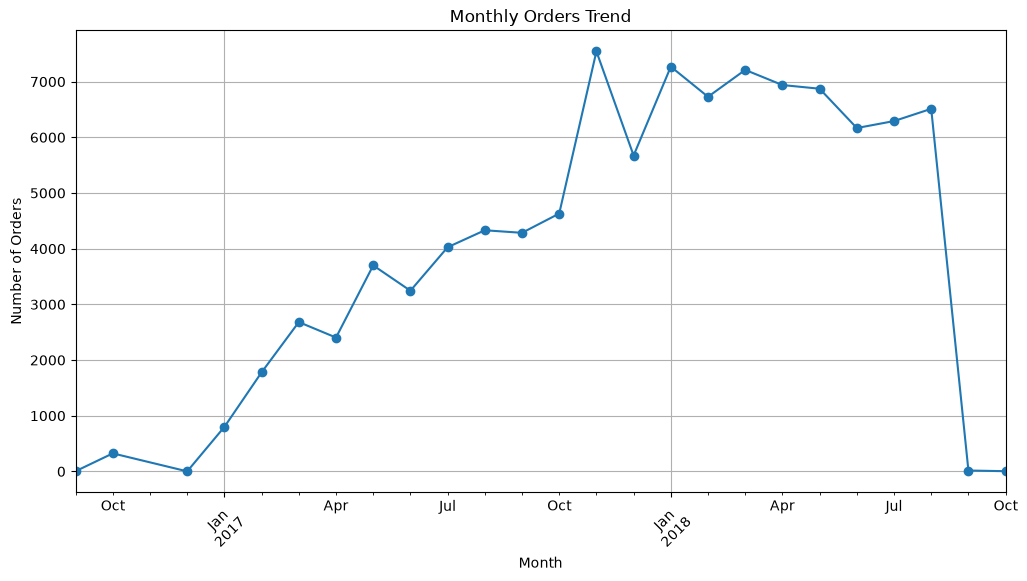

In [16]:
# ==========================================================
# Chart 10 : Monthly Order Trend
# Purpose:
# Analyze the number of orders placed each month.
# ==========================================================

orders["Year_Month"] = orders[
    "order_purchase_timestamp"
].dt.to_period("M")

monthly_orders = orders.groupby(
    "Year_Month"
).size()

plt.figure(figsize=(12,6))

monthly_orders.plot(
    marker="o"
)

plt.title("Monthly Orders Trend")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()